# AI-Based Financial Time Series Forecasting using LSTM

# Model Evaluation

## Objectives

- Load trained model
- Predict stock prices
- Convert predictions back to original scale
- Calculate evaluation metrics
- Visualize actual vs predicted prices

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

## Load Data

In [2]:
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")

scaler = joblib.load("../models/scaler.pkl")

model = load_model("../models/best_lstm_model.h5")

print("Files Loaded Successfully!")

Files Loaded Successfully!


## Prediction

In [3]:
predictions = model.predict(X_test)

print(predictions.shape)

66/66 [==============================] - 5s 34ms/step
(2082, 1)


## Inverse Transform

In [4]:
predicted_prices = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(y_test)

print("Converted back to original prices.")

Converted back to original prices.


## MAE

In [5]:
mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print("MAE :", round(mae,2))

MAE : 4.47


## RMSE

In [6]:
rmse = np.sqrt(

    mean_squared_error(
        actual_prices,
        predicted_prices
    )

)

print("RMSE :", round(rmse,2))

RMSE : 7.92


## Plot Actual vs Predicted

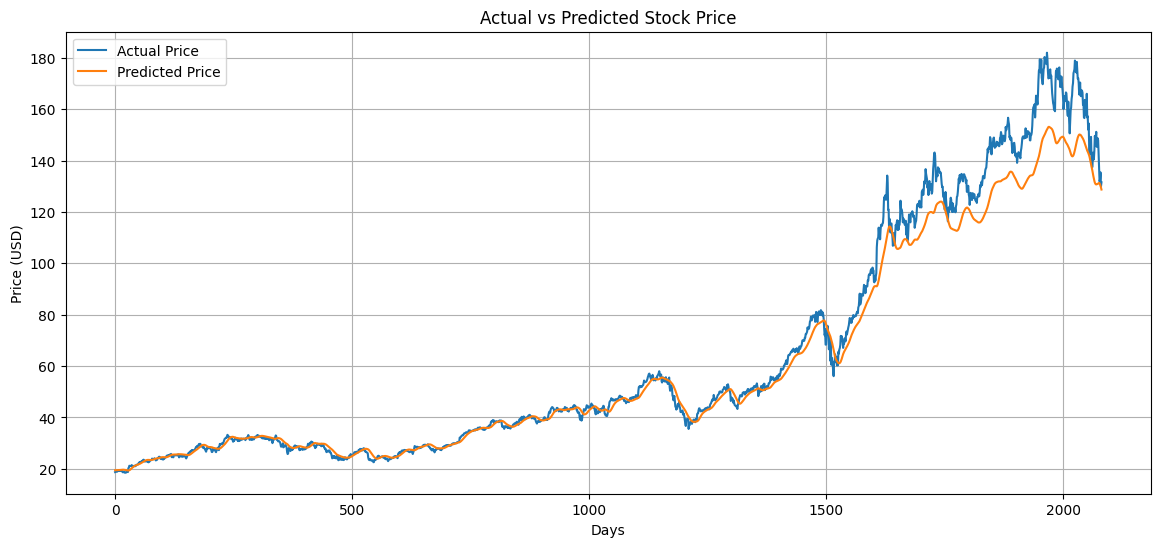

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predicted_prices,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Stock Price")

plt.xlabel("Days")

plt.ylabel("Price (USD)")

plt.legend()

plt.grid(True)

plt.show()

## Zoom View

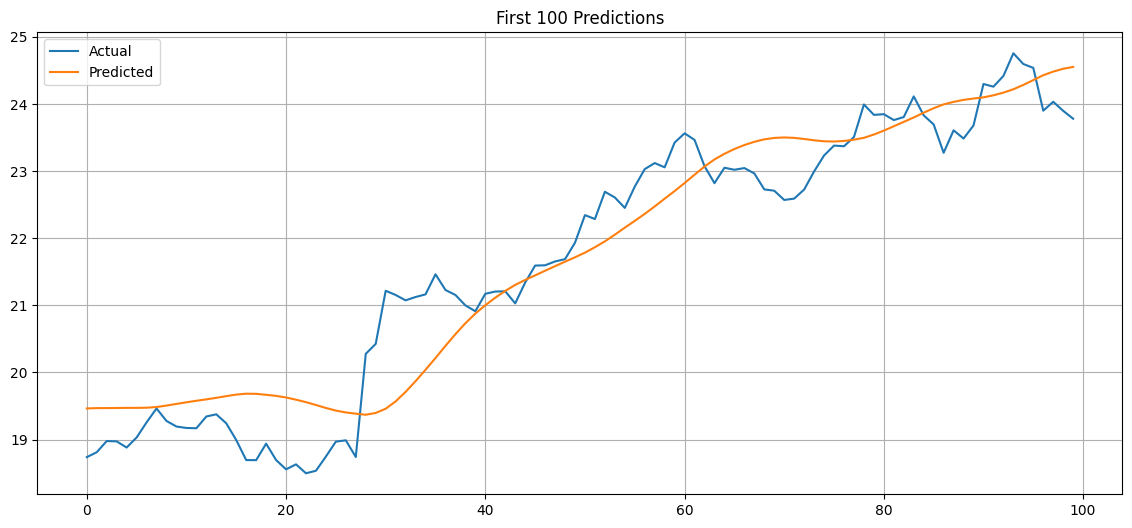

In [8]:
plt.figure(figsize=(14,6))

plt.plot(
    actual_prices[:100],
    label="Actual"
)

plt.plot(
    predicted_prices[:100],
    label="Predicted"
)

plt.title("First 100 Predictions")

plt.legend()

plt.grid(True)

plt.show()

## Sample Predictions

In [9]:
for i in range(10):

    print(

        f"Actual : {actual_prices[i][0]:.2f}"

        f" | Predicted : {predicted_prices[i][0]:.2f}"

    )

Actual : 18.74 | Predicted : 19.46
Actual : 18.81 | Predicted : 19.47
Actual : 18.98 | Predicted : 19.47
Actual : 18.97 | Predicted : 19.47
Actual : 18.88 | Predicted : 19.47
Actual : 19.03 | Predicted : 19.47
Actual : 19.26 | Predicted : 19.48
Actual : 19.46 | Predicted : 19.49
Actual : 19.28 | Predicted : 19.51
Actual : 19.20 | Predicted : 19.53


# Summary

Completed:

- Loaded trained model
- Generated predictions
- Converted predictions to original scale
- Calculated MAE
- Calculated RMSE
- Visualized Actual vs Predicted prices